In [10]:
import sys 
import os 
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix



In [11]:
PROJECT_ROOT = Path.cwd().parent
print("PROJECT ROOT ==>", PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))
from src.landmark_eval import compute_all_statistics
from src.var_constants import CATEGORIES

PROJECT ROOT ==> c:\Users\aless\Tesi_Msc\multi_agent_evaluation_on_intraoral_3D_scans


In [12]:
EXP_ID = "exp_v1_single_agent__20260912_223810" 
EXP_ID = "exp_v2_single_agent__20260912_234512" 
EXP_ID = "exp_v3_single_agent__20260913_010442" 


EXP_DIR = PROJECT_ROOT / "experiments" / EXP_ID
OUTPUTS_PATH = EXP_DIR / "outputs.json"
EVAL_PATH = EXP_DIR / "evaluation.json"
CONFIG_PATH = EXP_DIR / "config.json"

DATA_ROOT = PROJECT_ROOT / "dataset"
SCANS = DATA_ROOT / "toothinstancenet_input"
GT_ROOT = SCANS
PRED_CSV = DATA_ROOT / "model_predictions" / "ynlab" / "predictions.csv"
with open(OUTPUTS_PATH, "r") as f:
    outputs = json.load(f)

experiment_outputs_df = pd.DataFrame(outputs)
experiment_outputs_df.head()

,scan,real_quality,pred_quality,motivation
0,AKBDPB4C_upper,5,1,Molti landmark sono posizionati sulla gengiva ...
1,ANLLPLV7_upper,1,1,L'immagine di input non presenta alcun landmar...
2,CK45DVLG_upper,5,5,I landmark sono posizionati con elevata precis...
3,CLNVA9MZ_upper,2,1,La scansione presenta errori anatomici signifi...
4,CNUR69O9_upper,3,3,La qualità dei landmark è compromessa dalla pr...


MAE: 1.7333333333333334
Accuracy (exact): 0.2
Accuracy (±1): 0.4666666666666667


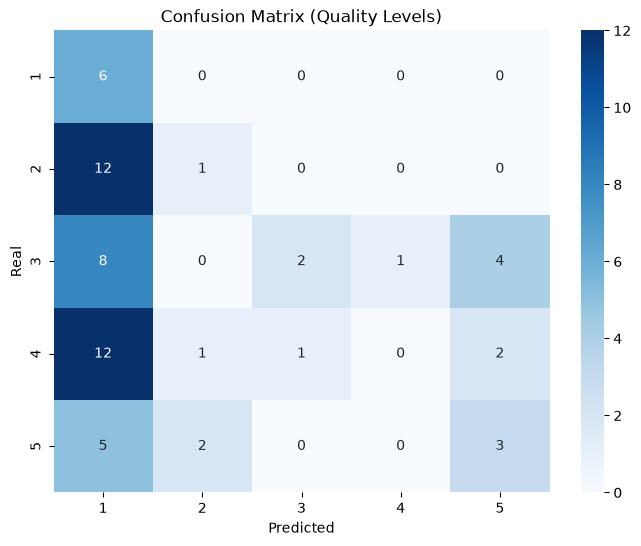

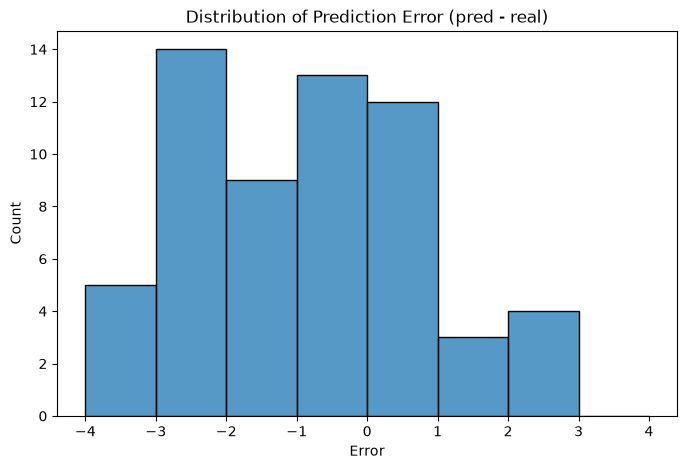

In [13]:

y_true = experiment_outputs_df["real_quality"].astype(int)
y_pred = experiment_outputs_df["pred_quality"].astype(int)

mae = np.mean(np.abs(y_true - y_pred))
acc_exact = np.mean(y_true == y_pred)
acc_pm1 = np.mean(np.abs(y_true - y_pred) <= 1)

print("MAE:", mae)
print("Accuracy (exact):", acc_exact)
print("Accuracy (±1):", acc_pm1)


cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix (Quality Levels)")
plt.show()

errors = y_pred - y_true

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=np.arange(-4,5), kde=False)
plt.title("Distribution of Prediction Error (pred - real)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()


#### analisi quantitativa rispetto ap

In [14]:
stats = compute_all_statistics(GT_ROOT, PRED_CSV, CATEGORIES)
stats_over_scan = stats["results"]

scans_list = stats_over_scan["scans"]          
mAP_list   = stats_over_scan["mAP_per_scan"]   
ap_map = dict(zip(scans_list, mAP_list))

experiment_outputs_df["AP_continuous"] = experiment_outputs_df["scan"].apply(
    lambda s: ap_map.get(s, np.nan)
)

experiment_outputs_df.head()

,scan,real_quality,pred_quality,motivation,AP_continuous
0,AKBDPB4C_upper,5,1,Molti landmark sono posizionati sulla gengiva ...,0.759437
1,ANLLPLV7_upper,1,1,L'immagine di input non presenta alcun landmar...,0.000000
2,CK45DVLG_upper,5,5,I landmark sono posizionati con elevata precis...,0.751863
3,CLNVA9MZ_upper,2,1,La scansione presenta errori anatomici signifi...,0.593302
4,CNUR69O9_upper,3,3,La qualità dei landmark è compromessa dalla pr...,0.679373


In [15]:
#CORRELAZIONE (Pearson e Spearman)
pearson_corr = experiment_outputs_df["pred_quality"].corr(experiment_outputs_df["AP_continuous"], method="pearson")
spearman_corr = experiment_outputs_df["pred_quality"].corr(experiment_outputs_df["AP_continuous"], method="spearman")

print("Pearson correlation (pred_quality vs AP):", pearson_corr)
print("Spearman correlation (pred_quality vs AP):", spearman_corr)


Pearson correlation (pred_quality vs AP): 0.2192225788906063
Spearman correlation (pred_quality vs AP): 0.2804371913548012


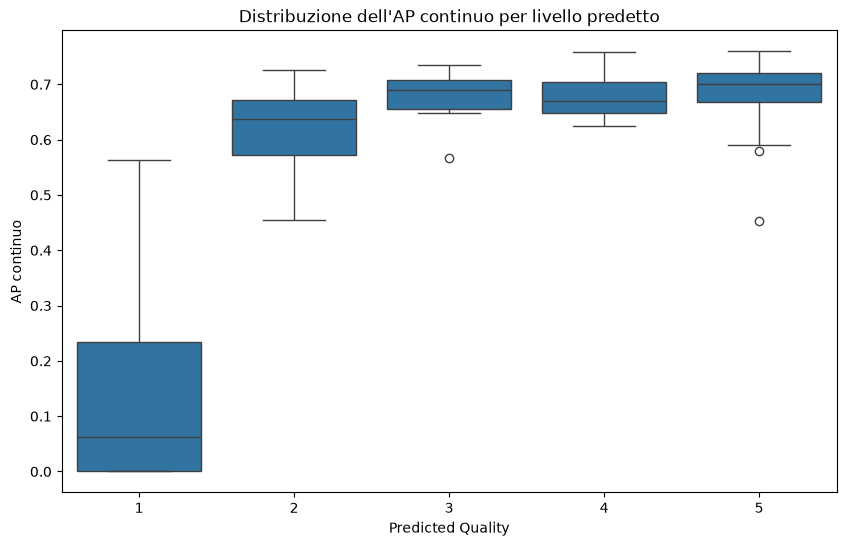

In [9]:
#BOXPLOT: AP per livello predetto
plt.figure(figsize=(10,6))
sns.boxplot(x=experiment_outputs_df["pred_quality"], y=experiment_outputs_df["AP_continuous"])
plt.xlabel("Predicted Quality")
plt.ylabel("AP continuo")
plt.title("Distribuzione dell'AP continuo per livello predetto")
plt.show()
